# AI-Generated SOAP Notes with MedGemma

This notebook demonstrates how to use **MedGemma**, Google's multimodal medical AI model, to automatically generate clinical SOAP notes from patient records.

## What is a SOAP Note?

SOAP notes are a standard format for clinical documentation:

| Section | Description |
|---------|-------------|
| **S**ubjective | Patient-reported symptoms, complaints, history |
| **O**bjective | Clinical findings: vitals, labs, imaging, exam |
| **A**ssessment | Diagnoses, clinical reasoning, risk factors |
| **P**lan | Treatment, follow-up, preventive care |

## The Challenge

Patients with long medical histories can have **thousands of clinical events**. This exceeds the context window of most LLMs. Our solution:

1. **Hierarchical Summarization**: Break history into time periods, summarize each
2. **Aggregation**: Combine period summaries into a comprehensive SOAP note
3. **Multimodal**: Include imaging (DICOM) when available

## Requirements

```bash
pip install synthlab torch transformers>=4.50.0 accelerate
```

**Note**: MedGemma requires a GPU with at least 16GB VRAM for the 4B model.

In [1]:
%load_ext autoreload
%autoreload 1
%aimport synthlab.soap
%aimport synthlab.causal_graph

import synthlab as sl
from synthlab.soap import SOAPNoteGenerator, generate_soap_note, FHIRFormatter

/home/schilder/.conda/envs/synthlab/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[01/26/26 11:52:32] INFO     Loading faiss.                                                           ]8;id=964452;file:///home/schilder/.conda/envs/synthlab/lib/python3.12/site-packages/faiss/loader.py\loader.py]8;;\:]8;id=867842;file:///home/schilder/.conda/envs/synthlab/lib/python3.12/site-packages/faiss/loader.py#133\133]8;;\

                    INFO     Successfully loaded faiss.                                               ]8;id=83953;file:///home/schilder/.conda/envs/synthlab/lib/python3.12/site-packages/faiss/loader.py\loader.py]8;;\:]8;id=99923;file:///home/schilder/.conda/envs/synthlab/lib/python3.12/site-packages/faiss/loader.py#135\135]8;;\


  ░██████╗██╗░░░██╗███╗░░██╗████████╗██╗░░██╗  ██╗░░░░░░█████╗░██████╗░
  ██╔════╝╚██╗░██╔╝████╗░██║╚══██╔══╝██║░░██║  ██║░░░░░██╔══██╗██╔══██╗
  ╚█████╗░░╚████╔╝░██╔██╗██║░░░██║░░░███████║  ██║░░░░░███████║██████╦╝
  ░╚═══██╗░░╚██╔╝░░██║╚████║░░░██║░░░██╔══██║  ██║░░░░░██╔══██║██╔══██╗
  ██████╔╝░░░██║░░░██║░╚███║░░░██║░░░██║░░██║  ███████╗██║░░██║██████╦╝
  ╚═════╝░░░░╚═╝░░░╚═╝░░╚══╝░░░╚═╝░░░╚═╝░░╚═╝  ╚══════╝╚═╝░░╚═╝╚═════╝░
        ▌║█║▌│║▌│║▌║▌█║▌║█║▌│║▌│║▌║▌█║▌║█║▌│║▌│║▌║▌█║▌│║▌│║▌║▌█║
  ════════════════════════════════════════════════════════════════════
  Synthetic Healthcare Data Toolkit
  ────────────────────────────────────────────────────────────────────
  ◈ EHR        Synthetic patient records (diagnoses, meds, labs)
  ◈ Genomics   Synthetic genotypes with realistic LD structure
  ◈ Imaging    Datasets + synthetic generation (CT, MRI, X-ray)
  ◈ Multimodal Linked EHR + Imaging + Genomics per patient
  ◈ AI Notes   SOAP notes with causal graph analysis
  ══════════════════

## 1. Load Patient Data

First, let's load patients from the Coherent Dataset. This dataset includes linked EHR (FHIR), imaging (DICOM), and genomics data.

In [2]:
# Load multimodal patient data
dataset = sl.load_multimodal_dataset(max_patients=10)

# Show summary
dataset.print_summary()

Indexing genomics: 100%|██████████| 889/889 [00:00<00:00, 447896.25file/s]
Indexing notes: 0file [00:00, ?file/s]

✓ Loaded 10 patients



Multimodal Dataset Summary

Total patients: 10

Modality coverage:
  fhir: 10 patients (100.0%)
  dicom: 2 patients (20.0%)
  genomics: 8 patients (80.0%)
  notes: 0 patients (0.0%)

Patients with all modalities: 2
Total DICOM files: 2
Total conditions: 131
Total medications: 1671


In [3]:
# Select a patient with rich clinical history
# Find patient with most conditions
patient = max(dataset, key=lambda p: len(p.get_conditions()))

demographics = patient.get_demographics()
print(f"Selected patient: {demographics['name']}")
print(f"Patient ID: {patient.patient_id}")
print(f"Gender: {demographics['gender']}")
print(f"Birth date: {demographics['birth_date']}")
print()
print(f"Clinical data:")
print(f"  Conditions: {len(patient.get_conditions())}")
print(f"  Medications: {len(patient.get_medications())}")
print(f"  Encounters: {len(patient.get_encounters())}")
print(f"  Observations: {len(patient.get_observations())}")
print(f"  Procedures: {len(patient.get_procedures())}")
print(f"  DICOM images: {len(patient.dicom_paths)}")

Selected patient: Alejandro916 Konopelski743
Patient ID: 967d5226-f8c4-60a8-b882-6ef803af88a6
Gender: male
Birth date: 1930-04-29

Clinical data:
  Conditions: 20
  Medications: 182
  Encounters: 323
  Observations: 2243
  Procedures: 45
  DICOM images: 1


## 2. Preview Patient Data

Let's see what data will be sent to MedGemma. The `FHIRFormatter` converts FHIR bundles into structured text.

In [4]:
# Preview formatted patient data
formatted_data = FHIRFormatter.format_patient_for_llm(patient, max_tokens=10000)

print("Formatted patient data (preview):")
print("=" * 60)
print(formatted_data[:3000])
print("\n... [truncated for display] ...")
print(f"\nTotal characters: {len(formatted_data):,}")
print(f"Estimated tokens: ~{len(formatted_data) // 4:,}")

Formatted patient data (preview):
("## PATIENT DEMOGRAPHICS\nName: Alejandro916 Konopelski743\nGender: male\nDate of Birth: 1930-04-29\nAddress: 318 Russel Bay Apt 77, Charlton, MA, US\n\n## CONDITIONS / DIAGNOSES\n- 2021-03-23: Bullet wound [resolved]\n- 2019-10-19: Acute viral pharyngitis (disorder) [resolved]\n- 2018-08-11: Acute viral pharyngitis (disorder) [resolved]\n- 2017-06-27: Stroke [active]\n- 2015-05-28: Viral sinusitis (disorder) [resolved]\n- 2015-01-15: Viral sinusitis (disorder) [resolved]\n- 2013-08-27: Alzheimer's disease (disorder) [active]\n- 2013-01-11: Viral sinusitis (disorder) [resolved]\n- 2008-05-02: Silent micro-hemorrhage of brain (disorder) [active]\n- 2008-05-02: Numbness of face (finding) [active]\n- 2008-05-02: Abnormal gait (finding) [active]\n- 1998-10-06: Hyperlipidemia [active]\n- 1973-05-15: Hyperglycemia (disorder) [active]\n- 1973-05-15: Prediabetes [active]\n- 1970-09-12: Chronic sinusitis (disorder) [active]\n- 1970-05-05: Neuropathy due to typ

## 3. Understanding Hierarchical Summarization

For patients with long histories, we use a **hierarchical approach**:

```
┌─────────────────────────────────────────────────────────────┐
│                    PATIENT HISTORY                         │
├─────────────┬─────────────┬─────────────┬─────────────────┤
│  2000-2004  │  2005-2009  │  2010-2014  │    2015-2024    │
│  (Chunk 1)  │  (Chunk 2)  │  (Chunk 3)  │    (Chunk 4)    │
└──────┬──────┴──────┬──────┴──────┬──────┴────────┬────────┘
       │             │             │               │
       ▼             ▼             ▼               ▼
   Summary 1     Summary 2     Summary 3       Summary 4
       │             │             │               │
       └─────────────┴─────────────┴───────────────┘
                           │
                           ▼
                 ┌─────────────────┐
                 │   FINAL SOAP    │
                 │      NOTE       │
                 └─────────────────┘
```

This allows us to process decades of patient history while staying within context limits.

In [5]:
# Preview how patient history would be chunked
chunks = FHIRFormatter.chunk_by_time_period(patient, period_years=5)

print(f"Patient history spans {len(chunks)} time periods:")
print("=" * 60)

for start, end, chunk_text in chunks:
    # Count events in chunk
    sl.utils.count_tokens(chunk_text)
    lines = chunk_text.split("\n")
    print(f"\n{start} - {end}:")
    print(f"  Characters: {len(chunk_text):,}")
    print(f"  Preview: {chunk_text}")

Patient history spans 12 time periods:

1964 - 1968:
  Characters: 244
  Preview: ## PERIOD: 1964 - 1968

Conditions diagnosed:
  - Diabetes
  - Anemia (disorder)
  - Hypertriglyceridemia (disorder)
  - Metabolic syndrome X (disorder)

Medications prescribed:
  - Vitamin B 12 5 MG/ML Injectable Solution

Encounters: 3 visits

1969 - 1973:
  Characters: 438
  Preview: ## PERIOD: 1969 - 1973

Conditions diagnosed:
  - Neuropathy due to type 2 diabetes mellitus (disorder)
  - Chronic sinusitis (disorder)
  - Hyperglycemia (disorder)
  - Prediabetes

Medications prescribed:
  - 24 HR Metformin hydrochloride 500 MG Extended Release Oral Tablet
  - 24 HR Metformin hydrochloride 500 MG Extended Release Oral Tablet
  - 24 HR Metformin hydrochloride 500 MG Extended Release Oral Tablet

Encounters: 4 visits

1974 - 1978:
  Characters: 489
  Preview: ## PERIOD: 1974 - 1978

Medications prescribed:
  - 24 HR Metformin hydrochloride 500 MG Extended Release Oral Tablet
  - 24 HR Metformin hydrochlor

In [6]:
patient.genomics

INDEX,INDEX_PREFIX,CHROMOSOME,LOCATION,STRAND,ANCESTRAL_ALLELE,VARIANT_ALLELE_LIST,GENE,CLINICAL_SIGNIFICANCE,ALLELE,VARIANT
str,str,i64,i64,i64,str,str,str,str,str,bool
"""rs1126742_FS1""","""rs1126742""",1,46932824,1,"""A""","""G""","""CYP4A11""","""Uncertain""","""A""",false
"""rs1126742_FS2""","""rs1126742""",1,46932824,2,"""A""","""G""","""CYP4A11""","""Uncertain""","""A""",false
"""rs11591147_FS1""","""rs11591147""",1,55039974,1,"""G""","""A, T""","""PCSK9""","""Pathogenic""","""G""",false
"""rs11591147_FS2""","""rs11591147""",1,55039974,2,"""G""","""A, T""","""PCSK9""","""Pathogenic""","""G""",false
"""rs16847548_FS1""","""rs16847548""",1,162065484,1,"""T""","""C""","""Unlisted""","""Uncertain""","""T""",false
…,…,…,…,…,…,…,…,…,…,…
"""rs1041740_FS2""","""rs1041740""",21,31667849,2,"""C""","""T""","""SOD1""","""Uncertain""","""C""",false
"""rs1805127_FS1""","""rs1805127""",21,34449523,1,"""T""","""C""","""KCNE1""","""Benign""","""T""",false
"""rs1805127_FS2""","""rs1805127""",21,34449523,2,"""T""","""C""","""KCNE1""","""Benign""","""T""",false


## 4. Generate SOAP Note

Now let's generate the SOAP note using MedGemma. The generator will:
1. Analyze the patient history length
2. Choose direct or hierarchical approach
3. Optionally include DICOM images
4. Generate structured SOAP output

### Build the SNOMED index

We need to build the SNOMED index before we can use the SOAP note generator. 

This lets us align concepts extracted from the EHR to controlled SNOMED terms (very useful for causal graph construction).

This will download the vocabulary (~29MB) and build a vector database of all SNOMED terms using an embeedding model.

In [7]:
import synthlab as sl                                                                                          
                                                                                                                
# This will auto-download from your private repo and build the index                                           
embedding_model_id = "Qwen/Qwen3-Embedding-0.6B"
linker = sl.load_snomed_linker(model_id=embedding_model_id, 
                                    # force=True
                                    )                                                                               
                                                                                                                
# # Or test just the download:                                                                                     
# sl.download_snomed_vocabulary(force=True)  

Loading SNOMED index: snomed_full_349211_qwen3_0.6b.index (349,211 concepts)
Loading embedding model: Qwen/Qwen3-Embedding-0.6B


[01/26/26 11:52:39] INFO     Load pretrained SentenceTransformer:                        ]8;id=809523;file:///home/schilder/.conda/envs/synthlab/lib/python3.12/site-packages/sentence_transformers/SentenceTransformer.py\SentenceTransformer.py]8;;\:]8;id=377526;file:///home/schilder/.conda/envs/synthlab/lib/python3.12/site-packages/sentence_transformers/SentenceTransformer.py#227\227]8;;\
                             Qwen/Qwen3-Embedding-0.6B                                                             

`torch_dtype` is deprecated! Use `dtype` instead!


[01/26/26 11:52:41] INFO     1 prompt is loaded, with the key: query                     ]8;id=943284;file:///home/schilder/.conda/envs/synthlab/lib/python3.12/site-packages/sentence_transformers/SentenceTransformer.py\SentenceTransformer.py]8;;\:]8;id=520609;file:///home/schilder/.conda/envs/synthlab/lib/python3.12/site-packages/sentence_transformers/SentenceTransformer.py#378\378]8;;\

  Loaded via sentence-transformers
  Flash Attention 2: enabled
  Device: cuda


In [8]:
out =linker.link("Alzheimer's")
out

[SNOMEDMatch(concept_id='26929004', term="Alzheimer's disease", score=0.9748426675796509, semantic_type='Disorder'),
 SNOMEDMatch(concept_id='52448006', term='Dementia', score=0.9361522197723389, semantic_type='Disorder'),
 SNOMEDMatch(concept_id='15662003', term='Senile dementia', score=0.9019885063171387, semantic_type='Disorder'),
 SNOMEDMatch(concept_id='394877006', term="FH: Alzheimer's disease", score=0.8819950819015503, semantic_type='Context-dependent'),
 SNOMEDMatch(concept_id='160325007', term='FH: Senile dementia', score=0.8712798357009888, semantic_type='Context-dependent')]

In [9]:
# Initialize the SOAP note generator
# Note: This will download MedGemma on first run (~8GB)

generator = SOAPNoteGenerator(
    # ----- Model and Device -------
    model_id="google/medgemma-1.5-4b-it",    # 4B parameter model
    device="auto",                           # Auto-select GPU
    multi_gpu=False,                         # Distribute across all GPUs
    gpu_memory_fraction=0.9,                 # Use 90% of each GPU's memory
    torch_dtype="bfloat16",                  # Memory-efficient dtype

    # ----- Sampling & Output -------
    do_sample=False, # Set to False for deterministic output
    repetition_penalty=1.2,
    # temperature=0.7,
    # top_p=0.9,

    # ----- Chunking / Summarization -------
    chunk_period_years=None,                 # Years per chunk

    # ----- NER & Causal Graph -------
    entity_extraction_model="google/medgemma-1.5-4b-it",
    separate_causal_graph=True,

    # ----- Imaging -------
    include_imaging=True,                    # Include DICOM images if available
    max_images=3,                            # Max images to include

    # ----- Genomics -------
    use_biomcp=True,                         # Use BioMCP to get more info on genetics

    # ----- SNOMED / Grounding -------
    ground_snomed=True,
    grounded_graph_mode=True,
    snomed_embedding_model=embedding_model_id,

    # ----- Misc -------
    verbose=2,                            # Show progress
)

SOAPNoteGenerator initialized:
  Model: google/medgemma-1.5-4b-it
  Device: auto
  Imaging: enabled (max 3 images)
  Chunking: disabled (direct mode only)
  Generation limits:
    max_new_tokens_chunk: 8,192
    max_new_tokens_final: 8,192
  Sampling: do_sample=False, repetition_penalty=1.2
  BioMCP: enabled
  Separate causal graph: enabled
  Causal graph: excluding admissions (default)
  SNOMED grounding: enabled (Qwen/Qwen3-Embedding-0.6B, two-stage mode)


In [ ]:
# Generate SOAP note
# This may take ~1-2 min (including images) depending on patient history length 
# To speed up further, ensure torchvision and flash-attn are installed
soap_note = generator.generate(
    patient,
)
# soap_note

SOAP: Alejandro Ko:   0%|          | 0/6 [00:00<?, ?it/s, BioMCP: enriching variants]

    [DEBUG] format_patient_for_llm: include_genomics=True, calling _format_genomics
    [DEBUG] _format_genomics called: use_biomcp=True, df_type=<class 'polars.dataframe.frame.DataFrame'>
    [DEBUG] genomics_df has 322 rows
    [DEBUG] Filtered VARIANT==True: 40 variants
    [DEBUG] Categorized 26 unique variants into 4 categories
    [DEBUG]   Uncertain: 20 variants (20 with rs prefix)
    [DEBUG]   Risk Factor: 4 variants (4 with rs prefix)
    [DEBUG]   Drug Response: 1 variants (1 with rs prefix)
    [DEBUG]   Benign: 1 variants (1 with rs prefix)
    [DEBUG] BioMCP available, processing variants
    [DEBUG] categorized has 4 categories: ['Uncertain', 'Risk Factor', 'Drug Response', 'Benign']
    [DEBUG] Found 26 rsIDs starting with 'rs'
    [DEBUG] Calling annotate_variants_biomcp with 26 prioritized rsIDs
    [DEBUG] annotate_variants_biomcp called with 26 rsIDs, max=20
    [DEBUG] First few rsIDs: ['rs699', 'rs4961', 'rs854560', 'rs4994', 'rs662799']
    [DEBUG] Querying first

[01/26/26 11:52:42] INFO     Adding external annotations for 1 variants                                ]8;id=915009;file:///home/schilder/.conda/envs/synthlab/lib/python3.12/site-packages/biomcp/variants/getter.py\getter.py]8;;\:]8;id=167355;file:///home/schilder/.conda/envs/synthlab/lib/python3.12/site-packages/biomcp/variants/getter.py#94\94]8;;\

                    INFO     Processing variant 0: keys=['_id', '_version', 'cadd', 'chrom',          ]8;id=680867;file:///home/schilder/.conda/envs/synthlab/lib/python3.12/site-packages/biomcp/variants/getter.py\getter.py]8;;\:]8;id=167138;file:///home/schilder/.conda/envs/synthlab/lib/python3.12/site-packages/biomcp/variants/getter.py#100\100]8;;\
                             'clinvar', 'cosmic', 'dbnsfp', 'dbsnp', 'evs', 'exac', 'exac_nontcga',                
                             'gnomad_exome', 'gnomad_genome', 'grasp', 'hg19', 'mutdb', 'observed',                
                             'snpeff', 'vcf', 'wellderly', 'url']                                                  

                    INFO     get_enhanced_annotations called for rs699, include_cbioportal=True     ]8;id=24109;file:///home/schilder/.conda/envs/synthlab/lib/python3.12/site-packages/biomcp/variants/external.py\external.py]8;;\:]8;id=915837;file:///home/schilder/.conda/envs/synthlab/lib/python3.12/site-packages/biomcp/variants/external.py#494\494]8;;\

...

Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.


    [DEBUG] Pipeline output type: <class 'list'>
    [DEBUG] Pipeline output: [{'input_text': [{'role': 'system', 'content': [{'type': 'text', 'text': 'You output ONLY causal relationships. No prose, no explanations, no commentary.\n\nFORMAT: Source[SNOMED:ID] ARROW Target[SNOMED:ID]\n\nARROWS:\n- ++> strongly increases risk\n- +> increases risk\n- --> treats / protects against\n- => directly causes\n\nINTERACTIONS:\n- A && B => C (both required)\n- A || B => C (either sufficient)\n\nEXAMPLE OUTPUT:\nType_2_Diabetes[SNOMED:44054006] ++> Chronic_kidney_disease[SNOMED:709044004]\nHypertension[SNOMED:38341003] ++> Stroke[SNOMED:230690007]\nMetformin[SNOMED:372567009] --> Type_2_Diabetes[SNOMED:44054006]\nSmoking[SNOMED:77176002] && Obesity[SNOMED:414916001] ++> Coronary_artery_disease[SNOMED:53741008]\nBRCA1_Mutation[SNOMED:412734009] || BRCA2_Mutation[SNOMED:412738007] || PALB2_Mutation[SNOMED:702464007] ++> Breast_Cancer[SNOMED:254837009]\n\nOutput one relationship per line. Nothing els

SOAP: Alejandro Ko: 100%|██████████| 6/6 [07:07<00:00, 71.22s/it, Done]                                           

    [DEBUG] Pipeline output type: <class 'list'>
    [DEBUG] Pipeline output: [{'input_text': [{'role': 'system', 'content': [{'type': 'text', 'text': 'You output ONLY causal relationships. No prose, no explanations, no commentary.\n\nFORMAT: Source[SNOMED:ID] ARROW Target[SNOMED:ID]\n\nARROWS:\n- ++> strongly increases risk\n- +> increases risk\n- --> treats / protects against\n- => directly causes\n\nINTERACTIONS:\n- A && B => C (both required)\n- A || B => C (either sufficient)\n\nEXAMPLE OUTPUT:\nType_2_Diabetes[SNOMED:44054006] ++> Chronic_kidney_disease[SNOMED:709044004]\nHypertension[SNOMED:38341003] ++> Stroke[SNOMED:230690007]\nMetformin[SNOMED:372567009] --> Type_2_Diabetes[SNOMED:44054006]\nSmoking[SNOMED:77176002] && Obesity[SNOMED:414916001] ++> Coronary_artery_disease[SNOMED:53741008]\nBRCA1_Mutation[SNOMED:412734009] || BRCA2_Mutation[SNOMED:412738007] || PALB2_Mutation[SNOMED:702464007] ++> Breast_Cancer[SNOMED:254837009]\n\nOutput one relationship per line. Nothing els

SOAPNote(patient_id='967d5226-f8c4-60a8-b882-6ef803af88a6', patient_name='Alejandro916 Konopelski743', generated_at='2026-01-26T11:55:43.411979', patient_story='', subjective='The patient reports feeling generally well today but denies specific complaints regarding pain or discomfort. He states that while he does experience occasional numbness in his hands, it is intermittent and not bothersome currently. He confirms adherence to his prescribed medication regimen.', objective='Vital signs were obtained as follows: BP 130/80 mmHg, P 98 bpm, RR 14 breaths/min, T 37°C. Physical Exam revealed unremarkable skin integrity without lesions or rashes. Neurovascular status was intact bilaterally. Gait was normal. Lab results showed glucose at 68.02 mg/dL, BUN at 16.95 mg/dL, creatinine at 2.08 mg/dL, calcium at 9.44 mg/dL, electrolytes within normal limits, total cholesterol at 175.95 mg/dL, triglycerides at 147.71 mg/dL, LDL at 77.99 mg/dL, HDL at 68.43 mg/dL, Microalbumin Creatinine ratio at 2

## 5. View the SOAP Note

In [11]:
soap_note.token_summary_df()

,type,id,input_tokens,output_tokens,seconds
0,soap,None,4961.0,2943.0,138.056587
1,biomcp,None,NaN,NaN,38.173799


In [25]:
# Print the complete SOAP note
# print(soap_note.raw_response)
print(soap_note)

# SOAP Note: Alejandro916 Konopelski743
Generated: 2026-01-26T11:55:43.411979

## Summary
This patient presents with complex comorbidities including poorly managed diabetes leading to hypertensive nephropathy and peripheral neuropathy, cerebrovascular accident, Alzheimer's disease, and established cardiovascular risk factors. Current labs indicate moderately poor glycemic control and evidence of significant proteinuric kidney damage. Recommendations focus on optimizing diabetes management, lifestyle modification, appropriate referrals for cardiovascular evaluation, and close monitoring of renal function.

## Subjective
The patient reports feeling generally well today but denies specific complaints regarding pain or discomfort. He states that while he does experience occasional numbness in his hands, it is intermittent and not bothersome currently. He confirms adherence to his prescribed medication regimen.

## Objective
Vital signs were obtained as follows: BP 130/80 mmHg, P 98 bpm, RR

In [15]:
# Raw LLM output for relationships                                                                             
print(soap_note.causal_graph_raw)                                                                              
                                                                                                                
# The prompt that was sent                                                                                     
# print(soap_note.prompts_used.get("grounded_relationships", "")[:1000])              

**Input Analysis:**
- The input is a SOAP note summarizing a patient encounter.
- It includes diagnosis summaries, subjective information, objective findings (vitals, exam, labs, imaging), assessment, plan, and concepts related to the case.
- I need to identify direct cause-and-effect links between conditions, lab values, medications, procedures, etc., mentioned in the summary.
- The output must be strictly formatted as `Concept[SNOMED:ID] ++> Concept[SNOMED:ID]` or `Concept[SNOMED:ID] --+> Concept[SNOMED:ID]`.
- Each relationship should correspond to a single line.
- No introductory text, explanations, or comments allowed.

**Relationship Identification Strategy:**
1.  Go through the 'Assessment', 'Plan', and 'Concepts' sections primarily, as they explicitly state connections.
2.  Look for explicit statements linking diseases or symptoms to their causes or consequences.
3.  Identify links between lab results and diagnoses (e.g., elevated BUN/Cr -> Hypertensive Renal Disease; low album

Can extract specific components of the SOAP note.

In [18]:
# # Access individual sections programmatically
# print("SUBJECTIVE")
# print("-" * 40)
# print(soap_note.subjective)
# print()

# print("ASSESSMENT")
# print("-" * 40)
# print(soap_note.assessment)
# print()

# print("FUTURE CONSIDERATIONS")
# print("-" * 40)
# print(soap_note.future_considerations)

Can export the SOAP note as JSON for integration with other systems.

In [20]:
# print(soap_note.to_json())

### View the causal graph

CausalGraph: 6 nodes, 4 edges
Nodes: unknown=6
Edges: risk=4


(<Figure size 1200x800 with 1 Axes>, <Axes: >)

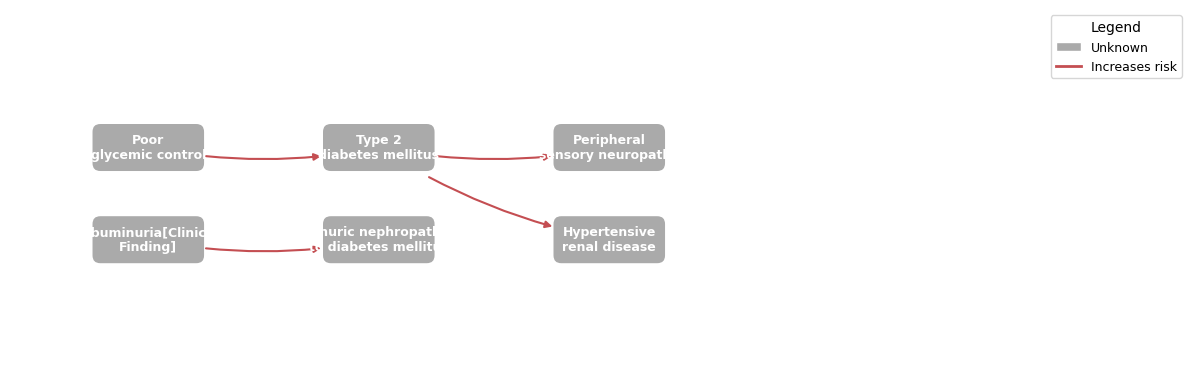

In [ ]:
graph = soap_note.extract_causal_graph()
print(graph.summary())

fig = graph.plot(
    interactive=False,
    font_color="#000000",
    # save_path="causal_graph.png"
)
fig                                                                                                                               

## 6. Batch Processing

Generate SOAP notes for multiple patients.

In [ ]:
# Generate SOAP notes for multiple patients
soap_notes = []

for i, patient in enumerate(dataset[:3]):  # First 3 patients
    print(f"\nProcessing patient {i+1}/3: {patient.name or patient.patient_id[:8]}...")
    
    note = generator.generate(patient, include_imaging=True)
    soap_notes.append(note)
    
    print(f"  ✓ Generated ({note.time_periods_summarized} time periods, {note.images_analyzed} images)")

print("\n" + "=" * 60)
print(f"Generated {len(soap_notes)} SOAP notes")

In [ ]:
# View summaries for all patients
print("Patient Summaries")
print("=" * 60)

for note in soap_notes:
    print(f"\n{note.patient_name or note.patient_id[:8]}:")
    print(f"  {note.summary[:200]}..." if len(note.summary) > 200 else f"  {note.summary}")

## 7. Simple One-Line API

For quick generation, use the convenience function:

In [ ]:
# One-line SOAP note generation
from synthlab.soap import generate_soap_note

quick_note = generate_soap_note(dataset[0])
print(quick_note.summary)

## Summary

```python
import synthlab as sl
from synthlab.soap import SOAPNoteGenerator, generate_soap_note

# Load patient data
dataset = sl.load_multimodal_dataset(max_patients=10)
patient = dataset[0]

# Quick generation
soap_note = generate_soap_note(patient)
print(soap_note)

# Or with more control
generator = SOAPNoteGenerator(
    model_id="google/medgemma-1.5-4b-it",
    chunk_period_years=5,
)
soap_note = generator.generate(patient, include_imaging=True)

# Access structured output
print(soap_note.subjective)
print(soap_note.assessment)
print(soap_note.future_considerations)

# Export
json_output = soap_note.to_json()
```

### Key Features

- **Hierarchical summarization** handles decades of patient history
- **Multimodal** includes DICOM imaging when available
- **Future-oriented** identifies potential health risks
- **Structured output** with SOAP sections + executive summary
- **Export-ready** JSON output for EHR integration